In [ ]:
print("I Love Langgraph !!!. 🚀")
print("Let's power through !!.")

In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END


def mock_llm(state: MessagesState):
    return {"message": [{"role": "ai", "content": "Hello world !!."}]} 


graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!."}]})


In [ ]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, MessagesState, START, END

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def mock_llm(state: MessagesState):
    return {"message": [{"role": "ai", "content": "Hello world !!."}]} 

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!."}]})


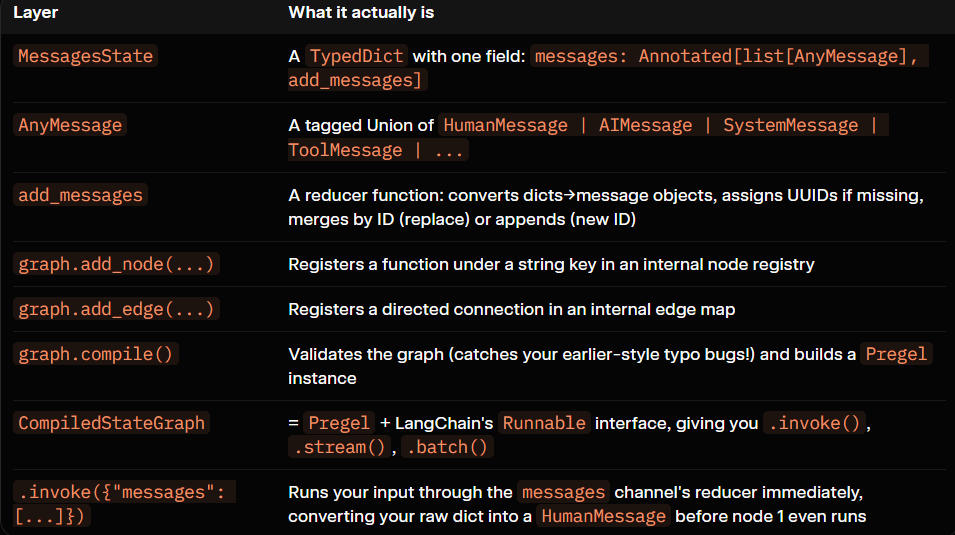

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    name: str
    greeting: str

def greet_node(state: State) -> dict:
    return {"greeting": f"Hello, {state['name']}!"}

graph = StateGraph(State)
graph.add_node("greet", greet_node)
graph.add_edge(START, "greet")
graph.add_edge("greet", END)

app = graph.compile()

result = app.invoke({"name": "karan", "greeting": ""})
print("Final state:", result)

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    text: str
    steps_done: list

def step_one(state: State) -> dict:
    print("  -> running step_one")
    return {
        "text": state["text"] + " [cleaned]",
        "steps_done": state["steps_done"] + ["step_one"]
    }

def step_two(state: State) -> dict:
    print("  -> running step_two")
    return {
        "text": state["text"] + " [validated]",
        "steps_done": state["steps_done"] + ["step_two"]
    }

def step_three(state: State) -> dict:
    print("  -> running step_three")
    return {
        "text": state["text"] + " [saved]",
        "steps_done": state["steps_done"] + ["step_three"]
    }

graph = StateGraph(State)
graph.add_node("step_one", step_one)
graph.add_node("step_two", step_two)
graph.add_node("step_three", step_three)

graph.add_edge(START, "step_one")
graph.add_edge("step_one", "step_two")
graph.add_edge("step_two", "step_three")
graph.add_edge("step_three", END)

app = graph.compile()

result = app.invoke({"text": "raw_data", "steps_done": []})
print()
print("Final text:", result["text"])
print("Steps executed in order:", result["steps_done"])

In [ ]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    value: int                                   # plain field -> last write wins (overwrite)
    history: Annotated[list, operator.add]        # reducer field -> auto-merged (append)

def add_five(state: State) -> dict:
    new_value = state["value"] + 5
    return {
        "value": new_value,
        "history": [f"add_five: {state['value']} -> {new_value}"]   # return ONLY the new item
    }

def double_it(state: State) -> dict:
    new_value = state["value"] * 2
    return {
        "value": new_value,
        "history": [f"double_it: {state['value']} -> {new_value}"]
    }

def subtract_three(state: State) -> dict:
    new_value = state["value"] - 3
    return {
        "value": new_value,
        "history": [f"subtract_three: {state['value']} -> {new_value}"]
    }

graph = StateGraph(State)
graph.add_node("add_five", add_five)
graph.add_node("double_it", double_it)
graph.add_node("subtract_three", subtract_three)

graph.add_edge(START, "add_five")
graph.add_edge("add_five", "double_it")
graph.add_edge("double_it", "subtract_three")
graph.add_edge("subtract_three", END)

app = graph.compile()

result = app.invoke({"value": 10, "history": []})
print("Final value:", result["value"])
print("History (auto-merged by reducer):")
for h in result["history"]:
    print("  -", h)

In [ ]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    current_stage: str                       # overwrite field: always reflects the LATEST stage
    log: Annotated[list, operator.add]        # accumulate field: keeps ALL stages ever visited
    counter: Annotated[int, operator.add]     # accumulate field: numbers can accumulate too!

def stage_a(state: State) -> dict:
    print(f"[stage_a] before: current_stage={state['current_stage']!r}, counter={state['counter']}")
    return {"current_stage": "A", "log": ["entered A"], "counter": 1}

def stage_b(state: State) -> dict:
    print(f"[stage_b] before: current_stage={state['current_stage']!r}, counter={state['counter']}")
    return {"current_stage": "B", "log": ["entered B"], "counter": 1}

def stage_c(state: State) -> dict:
    print(f"[stage_c] before: current_stage={state['current_stage']!r}, counter={state['counter']}")
    return {"current_stage": "C", "log": ["entered C"], "counter": 1}

graph = StateGraph(State)
graph.add_node("stage_a", stage_a)
graph.add_node("stage_b", stage_b)
graph.add_node("stage_c", stage_c)

graph.add_edge(START, "stage_a")
graph.add_edge("stage_a", "stage_b")
graph.add_edge("stage_b", "stage_c")
graph.add_edge("stage_c", END)

app = graph.compile()

result = app.invoke({"current_stage": "none", "log": [], "counter": 0})
print()
print("current_stage (OVERWRITE field) only shows the LAST value:", result["current_stage"])
print("log (ACCUMULATE field) shows EVERY value:", result["log"])
print("counter (ACCUMULATE field) summed every node's contribution:", result["counter"])

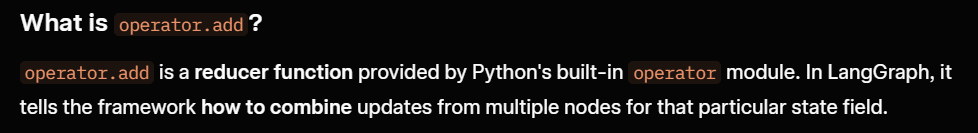
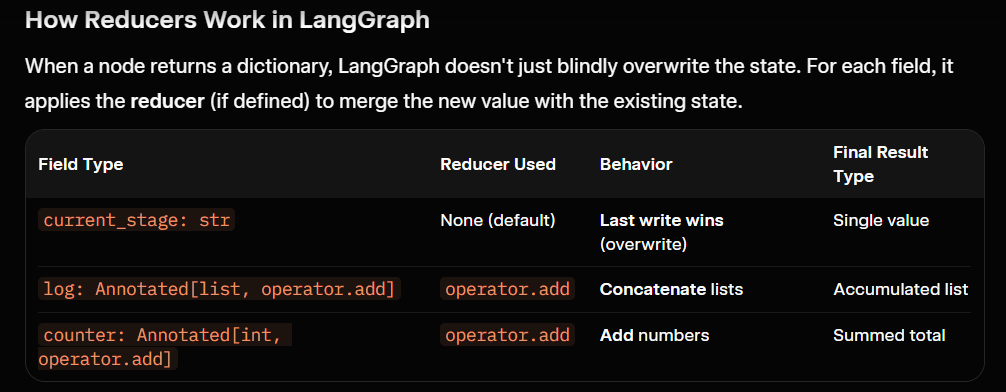

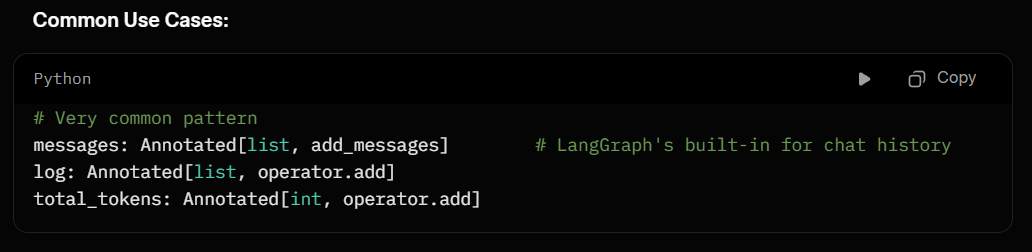

In [ ]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

# --- Custom reducer #1: merge lists but drop duplicates ---
def unique_merge(old: list, new: list) -> list:
    combined = old + new
    seen = []
    for item in combined:
        if item not in seen:
            seen.append(item)
    return seen

# --- Custom reducer #2: keep the running maximum, ignore lower values ---
def keep_max(old: int, new: int) -> int:
    return max(old, new)

class State(TypedDict):
    tags: Annotated[list, unique_merge]     # custom reducer #1
    high_score: Annotated[int, keep_max]    # custom reducer #2

def node_a(state: State) -> dict:
    return {"tags": ["python", "ai"], "high_score": 42}

def node_b(state: State) -> dict:
    # "python" is a duplicate -> should be dropped by unique_merge
    # 17 is lower than current high_score -> should be ignored by keep_max
    return {"tags": ["python", "graph"], "high_score": 17}

def node_c(state: State) -> dict:
    # 99 is higher -> keep_max should update to 99
    return {"tags": ["langgraph"], "high_score": 99}

graph = StateGraph(State)
graph.add_node("node_a", node_a)
graph.add_node("node_b", node_b)
graph.add_node("node_c", node_c)

graph.add_edge(START, "node_a")
graph.add_edge("node_a", "node_b")
graph.add_edge("node_b", "node_c")
graph.add_edge("node_c", END)

app = graph.compile()

result = app.invoke({"tags": [], "high_score": 0})
print("Final tags (deduplicated):", result["tags"])
print("Final high_score (max-only, never decreases):", result["high_score"])

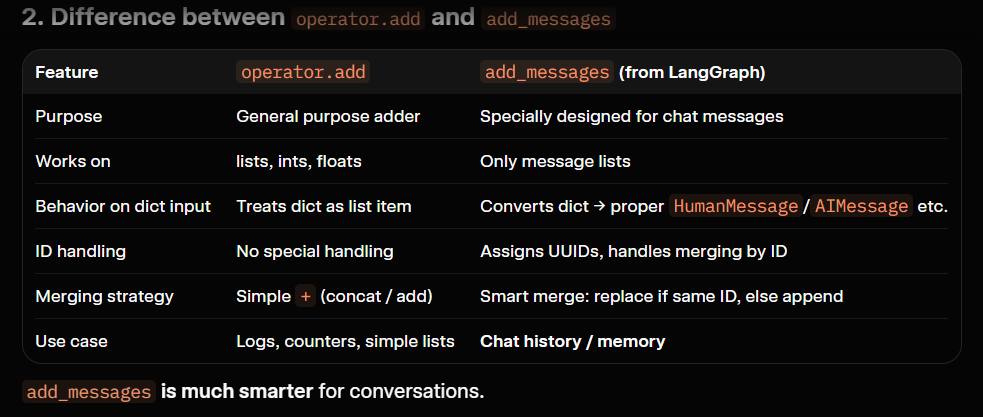

In [ ]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

# Custom reducer examples
def keep_latest(left, right):
    """Always keep the latest value (same as default behavior)"""
    return right

def merge_dicts(left: dict, right: dict):
    """Deep merge two dictionaries"""
    return {**left, **right}

def filter_unique(left: list, right: list):
    """Add only unique items (no duplicates)"""
    seen = set(left)
    for item in right:
        if item not in seen:
            left.append(item)
            seen.add(item)
    return left

# State with custom reducers
class State(TypedDict):
    current_stage: Annotated[str, keep_latest]           # explicit overwrite
    metadata: Annotated[dict, merge_dicts]
    unique_events: Annotated[list, filter_unique]
    total_cost: Annotated[float, lambda left, right: left + right]

# Example node
def node_a(state: State):
    return {
        "current_stage": "A",
        "metadata": {"model": "gpt-4o", "temperature": 0.7},
        "unique_events": ["user_asked_question"],
        "total_cost": 0.002
    }

In [ ]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]           # Chat memory
    next_step: str                                    # Overwrite (last wins)
    tool_calls: Annotated[list, operator.add]         # Accumulate tools used
    total_tokens: Annotated[int, operator.add]        # Accumulate tokens
    cost: Annotated[float, operator.add]              # Accumulate cost

def research_node(state: AgentState):
    # Simulate tool call
    tool_call = {
        "name": "web_search",
        "args": {"query": "latest AI agents developments"},
        "id": "call_123"
    }
    
    return {
        "messages": [AIMessage(
            content="I searched the web for latest AI agent news.",
            tool_calls=[tool_call]
        )],
        "tool_calls": ["web_search"],           # accumulates
        "total_tokens": 450,
        "cost": 0.0012,
        "next_step": "analyze"
    }

def analysis_node(state: AgentState):
    return {
        "messages": [AIMessage(
            content="Based on the research, here is the summary about AI agents..."
        )],
        "tool_calls": ["analyze_data"],
        "total_tokens": 320,
        "cost": 0.0008,
        "next_step": "finalize"
    }

# Build the graph
graph = StateGraph(AgentState)
graph.add_node("research", research_node)
graph.add_node("analysis", analysis_node)

graph.add_edge(START, "research")
graph.add_edge("research", "analysis")
graph.add_edge("analysis", END)

app = graph.compile()

# Run it
result = app.invoke({
    "messages": [HumanMessage(content="What is the latest on AI agents?")],
    "next_step": "start",
    "tool_calls": [],
    "total_tokens": 0,
    "cost": 0.0
})

# Output
print("Final State:")
print("Messages count:", len(result["messages"]))
print("Tool calls history:", result["tool_calls"])
print("Total tokens used:", result["total_tokens"])
print("Total cost:", f"${result['cost']:.4f}")
print("Final next_step:", result["next_step"])

In [ ]:
# Example 1: Resume Scorer
# Takes a resume text, extracts skills, scores it against a job description, gives a verdict.

In [1]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field   # Modern recommendation

# === Modern State Definition ===
class ResumeState(BaseModel):                    # Better than TypedDict
    resume_text: str
    job_description: str
    extracted_skills: Annotated[list[str], operator.add] = Field(default_factory=list)
    matched_skills: Annotated[list[str], operator.add] = Field(default_factory=list)
    score: Annotated[int, operator.add] = 0
    verdict: str = ""

# === Better Nodes (Return updates, don't mutate) ===
def extract_skills(state: ResumeState) -> dict:
    known_skills = {
        "python", "sql", "machine learning", "deep learning",
        "pandas", "numpy", "docker", "git", "fastapi", "tensorflow",
        "aws", "kubernetes", "react", "llm"   # Modern skills
    }
    
    text_lower = state.resume_text.lower()
    found = [skill for skill in known_skills if skill in text_lower]
    
    return {"extracted_skills": found}

def match_skills(state: ResumeState) -> dict:
    jd_lower = state.job_description.lower()
    matched = [s for s in state.extracted_skills if s in jd_lower]
    return {"matched_skills": matched}

def score_resume(state: ResumeState) -> dict:
    total = len(state.extracted_skills)
    matched = len(state.matched_skills)
    score = round((matched / total) * 100) if total > 0 else 0
    return {"score": score}

def give_verdict(state: ResumeState) -> dict:
    score = state.score
    if score >= 80:
        verdict = "Excellent Match - Strong Candidate"
    elif score >= 65:
        verdict = "Good Match - Consider for Interview"
    elif score >= 45:
        verdict = "Moderate Match - Further Review"
    else:
        verdict = "Weak Match - Not Recommended"
    return {"verdict": verdict}

# === Graph ===
graph = StateGraph(ResumeState)
graph.add_node("extract_skills", extract_skills)
graph.add_node("match_skills", match_skills)
graph.add_node("score_resume", score_resume)
graph.add_node("give_verdict", give_verdict)

graph.add_edge(START, "extract_skills")
graph.add_edge("extract_skills", "match_skills")
graph.add_edge("match_skills", "score_resume")
graph.add_edge("score_resume", "give_verdict")
graph.add_edge("give_verdict", END)

workflow = graph.compile()

# Run
initial_state = {
    "resume_text": "Experienced engineer skilled in Python, SQL, Pandas, NumPy, Docker, and Git.",
    "job_description": "We need a data engineer with Python, SQL, Docker, and TensorFlow experience.",
}

result = workflow.invoke(initial_state)

print("Extracted Skills :", result["extracted_skills"])
print("Matched Skills   :", result["matched_skills"])
print("Score            :", result["score"], "%")
print("Verdict          :", result["verdict"])

Extracted Skills : ['numpy', 'git', 'python', 'sql', 'docker', 'pandas']
Matched Skills   : ['python', 'sql', 'docker']
Score            : 50 %
Verdict          : Moderate Match - Further Review


In [2]:
# ! uv pip install ipython

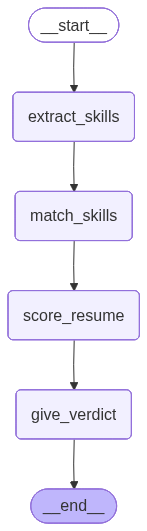

In [3]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
# ! uv pip install grandalf

In [12]:
# # 2. ASCII Art (Quick & Text-based)
# print(workflow.get_graph().draw_ascii())

# # 3. Get Mermaid Code (Useful for editing/customization)
# mermaid_code = workflow.get_graph().draw_mermaid()
# print(mermaid_code)

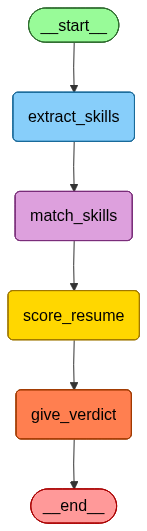

In [18]:
from IPython.display import Image, display
from langchain_core.runnables.graph_mermaid import draw_mermaid_png
from langchain_core.runnables.graph import MermaidDrawMethod

# Step 1: get the raw mermaid string LangGraph generates
raw = workflow.get_graph().draw_mermaid()

# Step 2: strip the default classDef lines (we will replace them)
lines = raw.split('\n')
lines = [line for line in lines if 'classDef' not in line]
clean = '\n'.join(lines)

# Step 3: append class assignments + your custom colors
# :::styleName assigns a style to a specific node by its exact name
custom = """
\textract_skills:::extractStyle
\tmatch_skills:::matchStyle
\tscore_resume:::scoreStyle
\tgive_verdict:::verdictStyle
\tclassDef default fill:#f2f0ff,line-height:1.2
\tclassDef first fill:#98fb98,stroke:#2d6a2d,color:#000
\tclassDef last fill:#ff9999,stroke:#a00,color:#000
\tclassDef extractStyle fill:#87cefa,stroke:#1a6a9a,color:#000,line-height:1.2
\tclassDef matchStyle fill:#dda0dd,stroke:#7a2d7a,color:#000,line-height:1.2
\tclassDef scoreStyle fill:#ffd700,stroke:#a07800,color:#000,line-height:1.2
\tclassDef verdictStyle fill:#ff7f50,stroke:#a03a00,color:#000,line-height:1.2
"""

final_mermaid = clean.rstrip() + '\n' + custom

# Step 4: render and display
png_bytes = draw_mermaid_png(
    mermaid_syntax=final_mermaid,
    draw_method=MermaidDrawMethod.API,
    background_color="white",
    padding=10
)

display(Image(png_bytes))

In [34]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

class CalcState(TypedDict):
    number: int
    result: int
    step: str

def add_five(state):
    return {"result": state["number"] + 5, "step": "Added 5"}

def multiply_by_two(state):
    return {"result": state["result"] * 2, "step": "Multiplied by 2"}

def subtract_three(state):
    return {"result": state["result"] - 3, "step": "Subtracted 3"}

graph = StateGraph(CalcState)
graph.add_node("add_five", add_five)
graph.add_node("multiply_by_two", multiply_by_two)
graph.add_node("subtract_three", subtract_three)

graph.add_edge(START, "add_five")
graph.add_edge("add_five", "multiply_by_two")
graph.add_edge("multiply_by_two", "subtract_three")
graph.add_edge("subtract_three", END)

workflow = graph.compile()

result = workflow.invoke({"number": 10, "result": 0})
print("Final Result:", result["result"])

Final Result: 27


In [35]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

class ReviewState(TypedDict):
    review: str
    sentiment: str

def analyze(state):
    text = state["review"].lower()
    positive = ["good", "great", "excellent", "love", "amazing"]
    negative = ["bad", "terrible", "worst", "hate"]
    
    if any(word in text for word in positive):
        sentiment = "Positive"
    elif any(word in text for word in negative):
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    
    return {"sentiment": sentiment}

graph = StateGraph(ReviewState)
graph.add_node("analyze", analyze)
graph.add_edge(START, "analyze")
graph.add_edge("analyze", END)

workflow = graph.compile()

result = workflow.invoke({"review": "This product is amazing and works perfectly!"})
print("Sentiment:", result["sentiment"])

Sentiment: Positive


In [19]:
# Example 2: E-Commerce Order Pipeline
# An order comes in, gets validated, inventory is checked, price is calculated with tax, and a receipt is generated.

In [24]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class OrderState(BaseModel):
    customer_name: str
    product: str
    quantity: int = 0
    unit_price: float = 0.0
    is_valid: bool = False
    in_stock: bool = False
    subtotal: Annotated[float, operator.add] = 0.0
    tax: Annotated[float, operator.add] = 0.0
    total: Annotated[float, operator.add] = 0.0
    receipt: str = ""

INVENTORY = {"laptop": 10, "mouse": 50, "keyboard": 0, "monitor": 5}
TAX_RATE = 0.18

def validate_order(state: OrderState):
    is_valid = (
        len(state.customer_name.strip()) > 0 and
        len(state.product.strip()) > 0 and
        state.quantity > 0
    )
    return {"is_valid": is_valid}

def check_inventory(state: OrderState):
    product = state.product.lower()
    available = INVENTORY.get(product, 0)
    return {"in_stock": available >= state.quantity}

def calculate_price(state: OrderState):
    subtotal = state.unit_price * state.quantity
    tax = round(subtotal * TAX_RATE, 2)
    total = round(subtotal + tax, 2)
    return {
        "subtotal": subtotal,
        "tax": tax,
        "total": total
    }

def generate_receipt(state: OrderState):
    if not state.is_valid:
        receipt = "FAILED: Invalid order details."
    elif not state.in_stock:
        receipt = f"FAILED: '{state.product}' is out of stock."
    else:
        receipt = (
            f"--- RECEIPT ---\n"
            f"Customer : {state.customer_name}\n"
            f"Product : {state.product} x {state.quantity}\n"
            f"Subtotal : Rs {state.subtotal}\n"
            f"Tax(18%) : Rs {state.tax}\n"
            f"Total : Rs {state.total}\n"
            f"Status : Confirmed"
        )
    return {"receipt": receipt}

graph = StateGraph(OrderState)
graph.add_node("validate_order", validate_order)
graph.add_node("check_inventory", check_inventory)
graph.add_node("calculate_price", calculate_price)
graph.add_node("generate_receipt", generate_receipt)

graph.add_edge(START, "validate_order")
graph.add_edge("validate_order", "check_inventory")
graph.add_edge("check_inventory", "calculate_price")
graph.add_edge("calculate_price", "generate_receipt")
graph.add_edge("generate_receipt", END)

workflow = graph.compile()

initial_state = {
    "customer_name": "Virat kholi",
    "product": "laptop",
    "quantity": 2,
    "unit_price": 75000.0
}

result = workflow.invoke(initial_state)
print(result["receipt"])

--- RECEIPT ---
Customer : Virat kholi
Product : laptop x 2
Subtotal : Rs 150000.0
Tax(18%) : Rs 27000.0
Total : Rs 177000.0
Status : Confirmed


In [25]:
# Example 3: Student Grade Report Generator
# Takes raw marks, calculates percentage, assigns a grade, checks pass/fail, generates a report card.

In [26]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class GradeState(TypedDict):
    student_name: str
    marks: dict          # {"subject": marks_obtained}
    max_marks: int
    total_obtained: int
    percentage: float
    grade: str
    passed: bool
    report: str

def calculate_total(state: GradeState) -> GradeState:
    state["total_obtained"] = sum(state["marks"].values())
    return state

def calculate_percentage(state: GradeState) -> GradeState:
    total_possible = state["max_marks"] * len(state["marks"])
    state["percentage"] = round(
        (state["total_obtained"] / total_possible) * 100, 2
    )
    return state

def assign_grade(state: GradeState) -> GradeState:
    p = state["percentage"]
    if p >= 90:
        grade = "A+"
    elif p >= 80:
        grade = "A"
    elif p >= 70:
        grade = "B"
    elif p >= 60:
        grade = "C"
    elif p >= 50:
        grade = "D"
    else:
        grade = "F"
    state["grade"] = grade
    state["passed"] = grade != "F"
    return state

def generate_report(state: GradeState) -> GradeState:
    lines = [
        f"===== REPORT CARD =====",
        f"Student   : {state['student_name']}",
        f"",
    ]
    for subject, mark in state["marks"].items():
        lines.append(f"  {subject:<15}: {mark} / {state['max_marks']}")

    lines += [
        f"",
        f"Total     : {state['total_obtained']}",
        f"Percentage: {state['percentage']}%",
        f"Grade     : {state['grade']}",
        f"Result    : {'PASS' if state['passed'] else 'FAIL'}",
    ]
    state["report"] = "\n".join(lines)
    return state

graph = StateGraph(GradeState)
graph.add_node("calculate_total", calculate_total)
graph.add_node("calculate_percentage", calculate_percentage)
graph.add_node("assign_grade", assign_grade)
graph.add_node("generate_report", generate_report)

graph.add_edge(START, "calculate_total")
graph.add_edge("calculate_total", "calculate_percentage")
graph.add_edge("calculate_percentage", "assign_grade")
graph.add_edge("assign_grade", "generate_report")
graph.add_edge("generate_report", END)

workflow = graph.compile()

initial_state: GradeState = {
    "student_name": "Priya Sharma",
    "marks": {
        "Mathematics": 88,
        "Physics": 76,
        "Chemistry": 91,
        "English": 83,
        "Computer Science": 95
    },
    "max_marks": 100,
    "total_obtained": 0,
    "percentage": 0.0,
    "grade": "",
    "passed": False,
    "report": ""
}

result = workflow.invoke(initial_state)
print(result["report"])

===== REPORT CARD =====
Student   : Priya Sharma

  Mathematics    : 88 / 100
  Physics        : 76 / 100
  Chemistry      : 91 / 100
  English        : 83 / 100
  Computer Science: 95 / 100

Total     : 433
Percentage: 86.6%
Grade     : A
Result    : PASS


In [27]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class GradeState(BaseModel):
    student_name: str
    marks: dict
    max_marks: int
    total_obtained: Annotated[int, operator.add] = 0
    percentage: Annotated[float, operator.add] = 0.0
    grade: str = ""
    passed: bool = False
    report: str = ""

def calculate_total(state: GradeState):
    total = sum(state.marks.values())
    return {"total_obtained": total}

def calculate_percentage(state: GradeState):
    total_possible = state.max_marks * len(state.marks)
    percentage = round((state.total_obtained / total_possible) * 100, 2)
    return {"percentage": percentage}

def assign_grade(state: GradeState):
    p = state.percentage
    if p >= 90:
        grade = "A+"
    elif p >= 80:
        grade = "A"
    elif p >= 70:
        grade = "B"
    elif p >= 60:
        grade = "C"
    elif p >= 50:
        grade = "D"
    else:
        grade = "F"
    
    return {
        "grade": grade,
        "passed": grade != "F"
    }

def generate_report(state: GradeState):
    lines = [
        "===== REPORT CARD =====",
        f"Student : {state.student_name}",
        ""
    ]
    for subject, mark in state.marks.items():
        lines.append(f" {subject:<15}: {mark} / {state.max_marks}")
    
    lines += [
        "",
        f"Total      : {state.total_obtained}",
        f"Percentage : {state.percentage}%",
        f"Grade      : {state.grade}",
        f"Result     : {'PASS' if state.passed else 'FAIL'}"
    ]
    return {"report": "\n".join(lines)}

# Build Graph
graph = StateGraph(GradeState)
graph.add_node("calculate_total", calculate_total)
graph.add_node("calculate_percentage", calculate_percentage)
graph.add_node("assign_grade", assign_grade)
graph.add_node("generate_report", generate_report)

graph.add_edge(START, "calculate_total")
graph.add_edge("calculate_total", "calculate_percentage")
graph.add_edge("calculate_percentage", "assign_grade")
graph.add_edge("assign_grade", "generate_report")
graph.add_edge("generate_report", END)

workflow = graph.compile()

# Run
initial_state = {
    "student_name": "Priya Sharma",
    "marks": {
        "Mathematics": 88,
        "Physics": 76,
        "Chemistry": 91,
        "English": 83,
        "Computer Science": 95
    },
    "max_marks": 100
}

result = workflow.invoke(initial_state)
print(result["report"])

===== REPORT CARD =====
Student : Priya Sharma

 Mathematics    : 88 / 100
 Physics        : 76 / 100
 Chemistry      : 91 / 100
 English        : 83 / 100
 Computer Science: 95 / 100

Total      : 433
Percentage : 86.6%
Grade      : A
Result     : PASS


In [28]:
# Example 4: Bank Loan Eligibility Pipeline
# Takes applicant details, checks minimum salary, calculates debt-to-income ratio, credit score check, final eligibility decision.

In [29]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class LoanState(TypedDict):
    applicant_name: str
    monthly_salary: float
    existing_emi: float
    requested_loan: float
    loan_tenure_months: int
    credit_score: int
    salary_check: bool
    dti_ratio: float
    dti_check: bool
    credit_check: bool
    emi_if_approved: float
    decision: str
    reason: str

def check_salary(state: LoanState) -> LoanState:
    # Minimum salary required: Rs 25,000/month
    state["salary_check"] = state["monthly_salary"] >= 25000
    return state

def check_dti_ratio(state: LoanState) -> LoanState:
    # DTI = (existing EMI + estimated new EMI) / monthly salary
    # Estimate new EMI assuming 10% annual interest
    monthly_rate = 0.10 / 12
    n = state["loan_tenure_months"]
    p = state["requested_loan"]
    new_emi = p * monthly_rate * ((1 + monthly_rate) ** n) / (((1 + monthly_rate) ** n) - 1)
    state["emi_if_approved"] = round(new_emi, 2)

    total_emi = state["existing_emi"] + new_emi
    dti = total_emi / state["monthly_salary"]
    state["dti_ratio"] = round(dti, 2)
    state["dti_check"] = dti <= 0.50  # DTI must be below 50%
    return state

def check_credit_score(state: LoanState) -> LoanState:
    # Minimum credit score: 700
    state["credit_check"] = state["credit_score"] >= 700
    return state

def make_decision(state: LoanState) -> LoanState:
    if not state["salary_check"]:
        state["decision"] = "REJECTED"
        state["reason"] = "Monthly salary below Rs 25,000 minimum requirement."
    elif not state["credit_check"]:
        state["decision"] = "REJECTED"
        state["reason"] = f"Credit score {state['credit_score']} is below minimum 700."
    elif not state["dti_check"]:
        state["decision"] = "REJECTED"
        state["reason"] = f"Debt-to-income ratio {state['dti_ratio']} exceeds 50% limit."
    else:
        state["decision"] = "APPROVED"
        state["reason"] = (
            f"All checks passed. EMI will be Rs {state['emi_if_approved']}/month "
            f"for {state['loan_tenure_months']} months."
        )
    return state

graph = StateGraph(LoanState)
graph.add_node("check_salary", check_salary)
graph.add_node("check_dti_ratio", check_dti_ratio)
graph.add_node("check_credit_score", check_credit_score)
graph.add_node("make_decision", make_decision)

graph.add_edge(START, "check_salary")
graph.add_edge("check_salary", "check_dti_ratio")
graph.add_edge("check_dti_ratio", "check_credit_score")
graph.add_edge("check_credit_score", "make_decision")
graph.add_edge("make_decision", END)

workflow = graph.compile()

initial_state: LoanState = {
    "applicant_name": "Rahul Mehta",
    "monthly_salary": 60000.0,
    "existing_emi": 5000.0,
    "requested_loan": 500000.0,
    "loan_tenure_months": 36,
    "credit_score": 740,
    "salary_check": False,
    "dti_ratio": 0.0,
    "dti_check": False,
    "credit_check": False,
    "emi_if_approved": 0.0,
    "decision": "",
    "reason": ""
}

result = workflow.invoke(initial_state)
print(f"Applicant : {initial_state['applicant_name']}")
print(f"Decision  : {result['decision']}")
print(f"Reason    : {result['reason']}")

Applicant : Rahul Mehta
Decision  : APPROVED
Reason    : All checks passed. EMI will be Rs 16133.59/month for 36 months.


In [30]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class LoanState(BaseModel):
    applicant_name: str
    monthly_salary: float
    existing_emi: float
    requested_loan: float
    loan_tenure_months: int
    credit_score: int
    
    salary_check: bool = False
    dti_ratio: float = 0.0
    dti_check: bool = False
    credit_check: bool = False
    emi_if_approved: float = 0.0
    decision: str = ""
    reason: str = ""

def check_salary(state: LoanState):
    return {"salary_check": state.monthly_salary >= 25000}

def check_dti_ratio(state: LoanState):
    monthly_rate = 0.10 / 12
    n = state.loan_tenure_months
    p = state.requested_loan
    
    # EMI Formula
    new_emi = p * monthly_rate * ((1 + monthly_rate) ** n) / (((1 + monthly_rate) ** n) - 1)
    total_emi = state.existing_emi + new_emi
    dti = total_emi / state.monthly_salary
    
    return {
        "emi_if_approved": round(new_emi, 2),
        "dti_ratio": round(dti, 2),
        "dti_check": dti <= 0.50
    }

def check_credit_score(state: LoanState):
    return {"credit_check": state.credit_score >= 700}

def make_decision(state: LoanState):
    if not state.salary_check:
        decision = "REJECTED"
        reason = "Monthly salary below Rs 25,000 minimum requirement."
    elif not state.credit_check:
        decision = "REJECTED"
        reason = f"Credit score {state.credit_score} is below minimum 700."
    elif not state.dti_check:
        decision = "REJECTED"
        reason = f"Debt-to-Income ratio {state.dti_ratio} exceeds 50% limit."
    else:
        decision = "APPROVED"
        reason = f"All checks passed. EMI will be Rs {state.emi_if_approved}/month for {state.loan_tenure_months} months."
    
    return {"decision": decision, "reason": reason}

# Build Graph
graph = StateGraph(LoanState)
graph.add_node("check_salary", check_salary)
graph.add_node("check_dti_ratio", check_dti_ratio)
graph.add_node("check_credit_score", check_credit_score)
graph.add_node("make_decision", make_decision)

graph.add_edge(START, "check_salary")
graph.add_edge("check_salary", "check_dti_ratio")
graph.add_edge("check_dti_ratio", "check_credit_score")
graph.add_edge("check_credit_score", "make_decision")
graph.add_edge("make_decision", END)

workflow = graph.compile()

# Run
initial_state = {
    "applicant_name": "Rohit Sharma",
    "monthly_salary": 60000.0,
    "existing_emi": 5000.0,
    "requested_loan": 500000.0,
    "loan_tenure_months": 36,
    "credit_score": 740
}

result = workflow.invoke(initial_state)

print(f"Applicant : {initial_state['applicant_name']}")
print(f"Decision  : {result['decision']}")
print(f"Reason    : {result['reason']}")

Applicant : Rohit Sharma
Decision  : APPROVED
Reason    : All checks passed. EMI will be Rs 16133.59/month for 36 months.


In [31]:
# Example 5: Product Review Sentiment Pipeline
# Takes a raw review, cleans it, detects sentiment, extracts keywords, gives a summary label for a dashboard.

In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import re

POSITIVE_WORDS = {
    "great", "excellent", "amazing", "love", "perfect", "good",
    "best", "fantastic", "awesome", "happy", "fast", "easy", "smooth"
}
NEGATIVE_WORDS = {
    "bad", "terrible", "awful", "hate", "worst", "slow", "broken",
    "useless", "poor", "horrible", "waste", "disappointing", "cheap"
}

class ReviewState(TypedDict):
    raw_review: str
    product_name: str
    cleaned_text: str
    tokens: list
    positive_hits: list
    negative_hits: list
    sentiment_score: int
    sentiment: str
    dashboard_label: str

def clean_text(state: ReviewState) -> ReviewState:
    text = state["raw_review"].lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)   # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    state["cleaned_text"] = text
    state["tokens"] = text.split()
    return state

def detect_sentiment(state: ReviewState) -> ReviewState:
    tokens = set(state["tokens"])
    pos_hits = list(tokens & POSITIVE_WORDS)
    neg_hits = list(tokens & NEGATIVE_WORDS)
    state["positive_hits"] = pos_hits
    state["negative_hits"] = neg_hits
    state["sentiment_score"] = len(pos_hits) - len(neg_hits)
    if state["sentiment_score"] > 0:
        state["sentiment"] = "Positive"
    elif state["sentiment_score"] < 0:
        state["sentiment"] = "Negative"
    else:
        state["sentiment"] = "Neutral"
    return state

def generate_dashboard_label(state: ReviewState) -> ReviewState:
    s = state["sentiment"]
    score = state["sentiment_score"]
    if s == "Positive" and score >= 3:
        label = "HIGHLIGHT - Feature in promotions"
    elif s == "Positive":
        label = "GOOD - Keep monitoring"
    elif s == "Neutral":
        label = "NEUTRAL - Needs follow-up"
    elif s == "Negative" and score <= -3:
        label = "URGENT - Escalate to product team"
    else:
        label = "NEGATIVE - Flag for review"
    state["dashboard_label"] = label
    return state

graph = StateGraph(ReviewState)
graph.add_node("clean_text", clean_text)
graph.add_node("detect_sentiment", detect_sentiment)
graph.add_node("generate_dashboard_label", generate_dashboard_label)

graph.add_edge(START, "clean_text")
graph.add_edge("clean_text", "detect_sentiment")
graph.add_edge("detect_sentiment", "generate_dashboard_label")
graph.add_edge("generate_dashboard_label", END)

workflow = graph.compile()

initial_state: ReviewState = {
    "raw_review": "This product is absolutely amazing! Fast delivery, easy setup, works perfectly. Love it!",
    "product_name": "Wireless Earbuds",
    "cleaned_text": "",
    "tokens": [],
    "positive_hits": [],
    "negative_hits": [],
    "sentiment_score": 0,
    "sentiment": "",
    "dashboard_label": ""
}

result = workflow.invoke(initial_state)
print(f"Product         : {result['product_name']}")
print(f"Positive Words  : {result['positive_hits']}")
print(f"Negative Words  : {result['negative_hits']}")
print(f"Sentiment Score : {result['sentiment_score']}")
print(f"Sentiment       : {result['sentiment']}")
print(f"Dashboard Label : {result['dashboard_label']}")

Product         : Wireless Earbuds
Positive Words  : ['love', 'easy', 'amazing', 'fast']
Negative Words  : []
Sentiment Score : 4
Sentiment       : Positive
Dashboard Label : HIGHLIGHT - Feature in promotions


In [33]:
from typing_extensions import TypedDict, Annotated
import operator
import re
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

POSITIVE_WORDS = {"great", "excellent", "amazing", "love", "perfect", "good",
                  "best", "fantastic", "awesome", "happy", "fast", "easy", "smooth"}

NEGATIVE_WORDS = {"bad", "terrible", "awful", "hate", "worst", "slow", "broken",
                  "useless", "poor", "horrible", "waste", "disappointing", "cheap"}

class ReviewState(BaseModel):
    raw_review: str
    product_name: str
    cleaned_text: str = ""
    tokens: list = []
    positive_hits: list = []
    negative_hits: list = []
    sentiment_score: Annotated[int, operator.add] = 0
    sentiment: str = ""
    dashboard_label: str = ""

def clean_text(state: ReviewState):
    text = state.raw_review.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    return {
        "cleaned_text": text,
        "tokens": tokens
    }

def detect_sentiment(state: ReviewState):
    tokens = set(state.tokens)
    pos_hits = list(tokens & POSITIVE_WORDS)
    neg_hits = list(tokens & NEGATIVE_WORDS)
    
    score = len(pos_hits) - len(neg_hits)
    
    if score > 0:
        sentiment = "Positive"
    elif score < 0:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    
    return {
        "positive_hits": pos_hits,
        "negative_hits": neg_hits,
        "sentiment_score": score,
        "sentiment": sentiment
    }

def generate_dashboard_label(state: ReviewState):
    s = state.sentiment
    score = state.sentiment_score
    
    if s == "Positive" and score >= 3:
        label = "HIGHLIGHT - Feature in promotions"
    elif s == "Positive":
        label = "GOOD - Keep monitoring"
    elif s == "Neutral":
        label = "NEUTRAL - Needs follow-up"
    elif s == "Negative" and score <= -3:
        label = "URGENT - Escalate to product team"
    else:
        label = "NEGATIVE - Flag for review"
    
    return {"dashboard_label": label}

# Build Graph
graph = StateGraph(ReviewState)
graph.add_node("clean_text", clean_text)
graph.add_node("detect_sentiment", detect_sentiment)
graph.add_node("generate_dashboard_label", generate_dashboard_label)

graph.add_edge(START, "clean_text")
graph.add_edge("clean_text", "detect_sentiment")
graph.add_edge("detect_sentiment", "generate_dashboard_label")
graph.add_edge("generate_dashboard_label", END)

workflow = graph.compile()

# Run
initial_state = {
    "raw_review": "This product is absolutely amazing! Fast delivery, easy setup, works perfectly. Love it!",
    "product_name": "Wireless Earbuds"
}

result = workflow.invoke(initial_state)

print(f"Product          : {result['product_name']}")
print(f"Positive Words   : {result['positive_hits']}")
print(f"Negative Words   : {result['negative_hits']}")
print(f"Sentiment Score  : {result['sentiment_score']}")
print(f"Sentiment        : {result['sentiment']}")
print(f"Dashboard Label  : {result['dashboard_label']}")

Product          : Wireless Earbuds
Positive Words   : ['love', 'easy', 'amazing', 'fast']
Negative Words   : []
Sentiment Score  : 4
Sentiment        : Positive
Dashboard Label  : HIGHLIGHT - Feature in promotions


In [36]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

model = init_chat_model("claude-sonnet-4-6", temperature=0)

@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add a and b."""
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b

tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [37]:
tools

[StructuredTool(name='add', description='Add a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001E065198FE0>),
 StructuredTool(name='multiply', description='Multiply a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001E0653A72E0>),
 StructuredTool(name='divide', description='Divide a and b.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000001E06EACA480>)]

In [38]:
tools_by_name

{'add': StructuredTool(name='add', description='Add a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001E065198FE0>),
 'multiply': StructuredTool(name='multiply', description='Multiply a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001E0653A72E0>),
 'divide': StructuredTool(name='divide', description='Divide a and b.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x000001E06EACA480>)}

In [6]:
import os
from langchain.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, ToolMessage
from dotenv import load_dotenv

load_dotenv()


model = ChatGroq(
    model="qwen/qwen3.6-27b",       
    temperature=0,
)

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide two numbers. Returns error message if division by zero."""
    if b == 0:
        return "Error: Division by zero"
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}

model_with_tools = model.bind_tools(tools)


def run_agent(query):
    print(f"Query: {query}\n")
    
    messages = [HumanMessage(content=query)]
    
    # First call
    response = model_with_tools.invoke(messages)
    messages.append(response)
    
    print("Tool calls:", response.tool_calls)   # ← Debugging
    
    if response.tool_calls:
        for tool_call in response.tool_calls:
            tool_name = tool_call["name"]
            args = tool_call["args"]
            
            print(f"Calling tool: {tool_name} with args: {args}")
            
            tool = tools_by_name.get(tool_name)
            if tool:
                tool_result = tool.invoke(args)
                messages.append(ToolMessage(
                    content=str(tool_result),
                    tool_call_id=tool_call.get("id"),
                    name=tool_name
                ))
        
        # Final response
        final_response = model_with_tools.invoke(messages)
        print("\nFinal Answer:", final_response.content)
    else:
        print("No tool calls. Direct response:", response.content)


# Test
run_agent("What is 25 multiplied by 4? Then add 100 to that result.")

Query: What is 25 multiplied by 4? Then add 100 to that result.

Tool calls: [{'name': 'multiply', 'args': {'a': 25, 'b': 4}, 'id': 'rzf3z64vv', 'type': 'tool_call'}]
Calling tool: multiply with args: {'a': 25, 'b': 4}

Final Answer: 


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LangChain | Structured Output 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from langchain_nebius import ChatNebius
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv

load_dotenv()

# ── model ─────────────────────────────────────────────────────────────
# model = ChatOpenRouter(model="z-ai/glm-5.1",temperature=0.7)
model = ChatNebius(model="MiniMaxAI/MiniMax-M2.5")

In [12]:
from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from typing import Literal
import os
from dotenv import load_dotenv
load_dotenv()


model = ChatNebius(model="MiniMaxAI/MiniMax-M2.5")

# ====================== TOOLS ======================
@tool
def research_topic(topic: str) -> str:
    """Research and return key points about a topic."""
    return f"Key points about {topic}: Innovation, market trends, use cases, and benefits."

@tool
def outline_blog(topic: str) -> str:
    """Create a structured outline for the blog post."""
    return f"Outline for {topic}:\n1. Introduction\n2. Main Benefits\n3. How it Works\n4. Real Examples\n5. Conclusion"

@tool
def write_section(section: str, content: str) -> str:
    """Write content for a specific section."""
    return f"Written section '{section}': Detailed and engaging content about {content}."

tools = [research_topic, outline_blog, write_section]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# ====================== STATE ======================
class BlogState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    topic: str
    blog_draft: str

# ====================== NODES ======================
def llm_call(state: BlogState):
    system_msg = SystemMessage(content="You are a professional blog writer. Use tools to research, outline, and write high-quality blog posts.")
    return {
        "messages": [
            model_with_tools.invoke([system_msg] + state["messages"])
        ]
    }

def tool_node(state: BlogState):
    result = []
    last_message = state["messages"][-1]
    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(
            content=observation,
            tool_call_id=tool_call["id"],
            name=tool_call["name"]
        ))
    return {"messages": result}

# ====================== ROUTING ======================
def should_continue(state: BlogState) -> Literal["tool_node", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return END

# ====================== BUILD GRAPH ======================
agent_builder = StateGraph(BlogState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()



In [ ]:
# ====================== RUN ======================
initial_input = {
    "messages": [HumanMessage(content="Write a blog post about the benefits of using LangGraph for building AI agents.")],
    "topic": "LangGraph for AI Agents",
    "blog_draft": ""
}

result = agent.invoke(initial_input)

print(result["messages"][-1].content)

In [9]:
from IPython.display import display, Markdown

initial_input = {
    "messages": [HumanMessage(content="Write a blog post about the benefits of using LangGraph for building AI agents.")],
    "topic": "LangGraph for AI Agents",
    "blog_draft": ""
}

result = agent.invoke(initial_input)

# print(result["messages"][-1].content)

content = result["messages"][-1].content
display(Markdown(content))

# Building Better AI Agents: The Benefits of Using LangGraph

## Introduction
LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain. It allows developers to create complex AI agents that can handle long-running processes, maintain state, and make decisions based on previous interactions. This section will introduce LangGraph and its significance in the AI landscape.

## Main Benefits
LangGraph offers several distinct advantages over traditional linear chains or simple agent loops. First, it provides robust **state management**, allowing agents to maintain context across long-running interactions. Second, it supports **cyclic graphs**, enabling complex logic like retries and loops that are difficult to implement with standard chains. Third, it facilitates **human-in-the-loop** workflows, making it easy to pause an agent for human approval before taking critical actions. Finally, its **persistence** features allow you to save and restore agent state, ensuring reliability even if the process is interrupted.

## How it Works
At its core, LangGraph models agent workflows as directed graphs. In this structure, **nodes** represent specific actions—such as calling an LLM, executing a tool, or performing a calculation—while **edges** define the flow of control between these actions. Unlike linear chains, LangGraph allows for cycles, meaning the agent can loop back to a previous step based on the outcome of the current one.

The system relies on a shared **state object** that is passed between nodes. This state acts as the agent's memory, storing information like the conversation history, intermediate results, or the current step in a process. By defining the graph topology and the state schema, developers can precisely control how the agent reasons and acts, moving beyond simple "prompt-and-response" patterns to sophisticated, multi-step workflows.

## Real Examples
To understand the power of LangGraph, consider a few practical scenarios.

**1. Customer Support Agent with Human Oversight:**
Imagine a support bot that handles basic queries but needs human intervention for refunds. Using LangGraph, you can create a node for the LLM to analyze the request. If the request is a refund, the edge leads to a "Human Review" node where the process pauses. Once a human approves or denies the action, the graph resumes to the final response node. This ensures safety without sacrificing automation for simple tasks.

**2. Complex Research Assistant:**
A research agent might need to search the web, read multiple documents, and synthesize findings. If the initial search results are insufficient, a standard chain might fail. With LangGraph, the agent can loop back to the search node with refined queries based on the initial findings, iterating until it has enough information to write a comprehensive report.

**3. Multi-Agent Collaboration:**
LangGraph allows for multi-actor applications. You could have a "Planner" agent that breaks down a task, a "Coder" agent that writes the code, and a "Reviewer" agent that checks for errors. The graph manages the handoff between these specialized agents, allowing them to collaborate on a complex software development task.

## Conclusion
LangGraph represents a significant leap forward in building production-grade AI agents. By moving beyond simple linear chains to stateful, cyclic graphs, it gives developers the control and flexibility needed to build robust, reliable, and complex applications. Whether you need to implement human-in-the-loop workflows, manage long-running processes, or coordinate multiple specialized agents, LangGraph provides the necessary infrastructure. As the field of AI agents continues to evolve, tools like LangGraph will be essential for turning experimental prototypes into dependable, real-world solutions.

In [13]:
### Run streaming

import asyncio
from langchain_core.messages import AIMessageChunk

initial_input = {
    "messages": [HumanMessage(content="Write a blog post about the benefits of using LangGraph for building AI agents.")],
    "topic": "LangGraph for AI Agents",
    "blog_draft": ""
}

print("=== Node-Level Streaming ===")
for step in agent.stream(initial_input):
    # 'step' is a dict like {'llm_call': {...}} or {'tool_node': {...}}
    print(step)



=== Node-Level Streaming ===
{'llm_call': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 321, 'total_tokens': 410, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'MiniMaxAI/MiniMax-M2.5', 'system_fingerprint': None, 'id': 'chatcmpl-8fa0fe80347c8754', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f1c32-80f2-7870-8d97-735e16864fde-0', tool_calls=[{'name': 'research_topic', 'args': {'topic': 'LangGraph AI agents benefits features'}, 'id': 'chatcmpl-tool-a044e48eb060d33f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 321, 'output_tokens': 89, 'total_tokens': 410, 'input_token_details': {}, 'output_token_details': {}})]}}
{'tool_node': {'messages': [ToolMessage(content='Key points about LangGraph AI agents benefits features: Innovation, market trends, use cases, and benefits.',

In [14]:
from IPython.display import display, Markdown, clear_output
from langchain_core.messages import AIMessageChunk

print("=== Streaming Text ===")
accumulated_content = ""

async for msg, metadata in agent.astream(initial_input, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk) and isinstance(msg.content, str) and msg.content:
        # 1. Print raw text for a smooth streaming effect
        print(msg.content, end="", flush=True)
        accumulated_content += msg.content

# 2. Clear the raw text and display the final rendered Markdown
clear_output(wait=True)
display(Markdown(accumulated_content))



I'll help you write a comprehensive blog post about LangGraph for building AI agents. Let me start by researching the topic to ensure I have accurate and up-to-date information.


























# The Benefits of Using LangGraph for Building AI Agents

*Building AI agents that can reason, iterate, and adapt to complex tasks has become one of the most exciting challenges in AI development today. As organizations seek to automate increasingly sophisticated workflows, the need for frameworks that support cyclical, stateful agent behavior has never been greater. Traditional pipeline approaches often fall short when agents need to loop back, re-evaluate, or refine their outputs through multiple iterations.*

*Enter LangGraph—a powerful extension of the LangChain ecosystem designed specifically for building stateful, multi-agent applications with cycles at their core. Whether you're creating a research assistant that gathers and synthesizes information, a coding agent that debugs and improves its own solutions, or a customer service bot that maintains context across extended conversations, LangGraph provides the architectural foundation you need.*

*In this post, we'll explore the key benefits of using LangGraph for building AI agents, how its graph-based approach transforms agent development, and real-world scenarios where it shines.*

---

## Main Benefits

LangGraph brings a range of powerful benefits that address the core challenges of building sophisticated AI agents. Here's why developers and organizations are increasingly adopting it:

**1. Native Cycle Support for Iterative Reasoning**

The standout feature of LangGraph is its first-class support for cycles. Unlike traditional linear pipelines, LangGraph allows agents to loop back on themselves—revisiting earlier steps, refining outputs, and iterating until conditions are met. This is essential for tasks like code generation where an agent might need to run tests, identify errors, and retry, or for research tasks where initial results trigger deeper investigation. Cycles turn a simple prompt-response model into a genuinely iterative reasoning process.

**2. Built-in State Management**

State management is notoriously difficult in agent systems. LangGraph handles it elegantly by maintaining state throughout the graph execution. Each node in the graph can read from and write to a shared state object, allowing the agent to accumulate context, remember prior decisions, and build on previous outputs across potentially many steps. This removes the burden of manually tracking conversation history or intermediate results.

**3. Multi-Agent Coordination Made Simple**

Complex applications often require multiple specialized agents working together—one for retrieval, another for reasoning, a third for execution. LangGraph provides clear patterns for coordinating multiple agents, allowing you to define how they communicate, delegate tasks, and share state. This makes it practical to build systems that combine the strengths of different models or tools.

**4. Fine-Grained Control Over Flow**

LangGraph gives you explicit control over the execution flow. You can define conditional branches, parallel execution, fallback strategies, and retry logic directly in the graph structure. This level of control is crucial when building production systems where you need to handle edge cases, enforce business logic, and ensure reliable behavior.

**5. Seamless Integration with LangChain**

As part of the LangChain ecosystem, LangGraph integrates smoothly with LangChain's extensive library of components—prompt templates, chat models, vector stores, tools, and more. If you're already using LangChain, adopting LangGraph is natural. You can leverage your existing integrations while adding the graph-based orchestration layer.

**6. Better Debugging and Observability**

Graph-based architectures are far easier to debug and visualize than opaque loops. You can literally see how data flows through your agent, inspect the state at each node, and identify exactly where things go wrong. This transparency accelerates development and makes it simpler to explain agent behavior to stakeholders.

**7. Persistence and Human-in-the-Loop Workflows**

LangGraph supports saving agent state at any point, enabling features like checkpointing, pause-and-resume workflows, and human-in-the-loop interventions. In production environments, the ability to pause an agent, have a human review its progress, and then let it continue is invaluable for safety-critical or high-stakes applications.

---

## How It Works

At its core, LangGraph models agent workflows as directed graphs. Each step in your agent's process becomes a **node**, and the connections between steps become **edges**. This simple abstraction provides tremendous flexibility.

### Nodes and Edges

- **Nodes** represent actions—calling a language model, fetching relevant documents from a vector store, running a function or tool, or making a decision based on current state. You write each node as a Python function that takes the current state, performs its task, and returns updates to that state.
- **Edges** define how the agent moves from one node to the next. They can be unconditional (always move from A to B) or conditional (decide between B and C based on the state). Conditional edges are where the intelligence lives—the agent evaluates its current context and chooses the next action.

### State Management

Every graph has a **state**—a shared dictionary-like object that flows through the graph. When a node executes, it receives the current state, performs its operation, and returns updates (often via a dictionary merge). These updates are applied to the state, which then moves to the next node. This pattern means you never lose context, and every node has access to everything the agent has done so far.

### The Cycle

What makes LangGraph special is that cycles are first-class citizens. You can define a graph where a node points back to an earlier one, creating a loop. The typical pattern looks like this: the agent performs an action, a conditional edge evaluates the result, and if more work is needed, the flow returns to an earlier node for another attempt. This is exactly how agents handle complex, multi-step tasks that require iteration.

### Persistence

LangGraph can store the graph's state at any point, enabling you to pause an agent, resume it later, or even replay its execution. This is built into the framework through checkpointers that integrate with various storage backends.

Here's a simplified example of how a self-correcting code agent might work in LangGraph:

- **Node 1**: Generate code using an LLM
- **Node 2**: Run tests on the generated code
- **Node 3**: If tests pass, return success; if they fail, return the error
- **Conditional edge**: If tests failed, go back to Node 1 with the error context; if passed, end

This cycle repeats until the code passes all tests—with each iteration, the agent gets better context about what's wrong, making its next attempt more likely to succeed.

---

## Real Examples

LangGraph's architecture shines in real-world applications where iterative reasoning and stateful workflows are essential. Here are some compelling use cases:

**1. Autonomous Code Agents**

One of the most natural applications for LangGraph is building code-generating agents that can debug and improve their own output. These agents follow a loop: generate code, run tests or linting, analyze any errors, and regenerate with fixes. LangGraph makes it straightforward to structure this cycle—each iteration gets full access to the previous attempts, error messages, and test results, dramatically improving success rates on complex coding tasks.

**2. Research and Synthesis Assistants**

Imagine an agent that performs web searches, reads multiple sources, identifies contradictions or gaps, and then loops back to search for additional information before producing a final report. LangGraph's cycle support is ideal here: you can define nodes for retrieval, analysis, and synthesis, with conditional edges that trigger additional search cycles when the agent determines its current results are insufficient.

**3. Multi-Agent Customer Support Systems**

In customer service scenarios, different agents might handle intent classification, knowledge base retrieval, order processing, and sentiment-aware response generation. LangGraph lets you orchestrate these agents as nodes in a graph, passing state between them and defining clear flows. If retrieval fails, the graph can route to a fallback; if sentiment is negative, it can escalate to a human agent.

**4. Document Processing Pipelines**

Extracting, validating, and enriching data from documents often requires multiple passes—parse the document, extract key fields, validate the extracted data, and if validation fails, re-parse with different instructions. LangGraph handles this elegantly, with the state carrying forward the document, extracted data, and validation errors through each iteration.

**5. Interactive Educational Tutors**

An AI tutor can use LangGraph to maintain student state across a lesson, dynamically adapting to a learner's responses. If a student struggles with a concept, the graph can loop back to re-explain it with different examples. The graph structure makes it easy to model branching lesson paths, assessment checkpoints, and personalized feedback loops.

---

## Conclusion

LangGraph represents a meaningful leap forward in the development of AI agents. By making cycles, state management, and multi-agent coordination first-class citizens within a clear architectural model, it tackles the fundamental challenges that have held back more sophisticated agent applications.

The graph-based approach brings clarity to what could otherwise become a tangled mess of loops and callbacks. You can visualize your agent's logic, reason about its behavior, debug issues with precision, and confidently deploy it into production—all thanks to the transparency and structure that LangGraph provides.

Perhaps most importantly, LangGraph doesn't ask you to abandon your existing tools. If you're already building with LangChain, moving to LangGraph is a natural evolution. You keep the ecosystem you love while gaining the power to build agents that reason, iterate, and adapt.

As AI agents move from experimental prototypes to production systems across industries, frameworks like LangGraph will be foundational. Whether you're building a code assistant, a research tool, a customer service system, or something entirely new, LangGraph gives you the building blocks to create agents that are not just smart, but genuinely capable of handling complex, real-world workflows.

If you haven't explored LangGraph yet, now is a great time to dive in. The combination of flexibility, control, and developer experience makes it one of the most compelling options for building the next generation of AI agents.

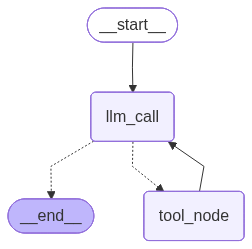

In [15]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [17]:
from langchain.tools import tool
from langchain_nebius import ChatNebius
from langchain_core.messages import HumanMessage, SystemMessage, AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Literal
import os
from dotenv import load_dotenv
load_dotenv()


# ── model 
# model = ChatOpenRouter(model="z-ai/glm-5.1",temperature=0.7)
model = ChatNebius(model="MiniMaxAI/MiniMax-M2.5")

@tool
def research_topic(topic: str) -> str:
    """Research and return key points about a topic."""
    return f"Key points about {topic}: Innovation, market trends, use cases, and benefits."

@tool
def outline_blog(topic: str) -> str:
    """Create a structured outline for the blog post."""
    return f"Outline for {topic}:\n1. Introduction\n2. Main Benefits\n3. How it Works\n4. Real Examples\n5. Conclusion"

@tool
def write_section(section: str, content: str) -> str:
    """Write content for a specific section."""
    return f"Written section '{section}': Detailed and engaging content about {content}."

tools = [research_topic, outline_blog, write_section]

# Bind tools to the model
model_with_tools = model.bind_tools(tools)

class BlogState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    topic: str
    blog_draft: str


def llm_call(state: BlogState):
    system_msg = SystemMessage(
        content="You are a professional blog writer. Use tools to research, outline, and write high-quality blog posts."
    )
    
    return {
        "messages": [
            model_with_tools.invoke([system_msg] + state["messages"])
        ]
    }

# Use prebuilt ToolNode (recommended)
tool_node = ToolNode(tools=tools)


agent_builder = StateGraph(BlogState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Edges
agent_builder.add_edge(START, "llm_call")

# Conditional routing using prebuilt tools_condition
agent_builder.add_conditional_edges(
    "llm_call",
    tools_condition,           # Much cleaner than custom function
    ["tool_node", END]
)

agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


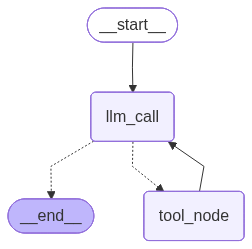

In [18]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [20]:
from langchain.tools import tool
from langchain_nebius import ChatNebius
from langchain_core.messages import HumanMessage, SystemMessage, AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from typing import Literal
import os
from dotenv import load_dotenv

load_dotenv()

model = ChatNebius(model="MiniMaxAI/MiniMax-M2.5")


@tool
def research_topic(topic: str) -> str:
    """Research and return key points about a topic."""
    return f"Key points about {topic}: Innovation, market trends, use cases, and benefits."

@tool
def outline_blog(topic: str) -> str:
    """Create a structured outline for the blog post."""
    return f"Outline for {topic}:\n1. Introduction\n2. Main Benefits\n3. How it Works\n4. Real Examples\n5. Conclusion"

@tool
def write_section(section: str, content: str) -> str:
    """Write content for a specific section."""
    return f"Written section '{section}': Detailed and engaging content about {content}."

tools = [research_topic, outline_blog, write_section]

model_with_tools = model.bind_tools(tools)


class BlogState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    topic: str
    blog_draft: str


def llm_call(state: BlogState):
    system_msg = SystemMessage(
        content="You are a professional blog writer. Use tools to research, outline, and write high-quality blog posts."
    )
    
    return {
        "messages": [
            model_with_tools.invoke([system_msg] + state["messages"])
        ]
    }

# Custom routing function (more reliable with custom state)
def should_continue(state: BlogState) -> Literal["tool_node", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return END


agent_builder = StateGraph(BlogState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", ToolNode(tools))

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()


from IPython.display import display, Markdown
from langchain_core.messages import AIMessageChunk

initial_state = {
    "messages": [HumanMessage(content="Write a blog post about Artificial Intelligence in Healthcare")],
    "topic": "Artificial Intelligence in Healthcare",
    "blog_draft": ""
}

# Streaming
display_handle = display(Markdown("*Thinking...*"), display_id=True)
accumulated_content = ""

async for event in agent.astream(initial_state, stream_mode="values"):
    if "messages" in event:
        last_msg = event["messages"][-1]
        
        if isinstance(last_msg, AIMessageChunk) and last_msg.content:
            accumulated_content += last_msg.content
            display_handle.update(Markdown(accumulated_content))

display_handle.update(Markdown(accumulated_content + "\n\n---\n**Generation Complete.**"))



---
**Generation Complete.**

In [ ]:
if __name__ == "__main__":
    initial_state = {
        "messages": [HumanMessage(content="Write a blog post about Artificial Intelligence in Healthcare")],
        "topic": "Artificial Intelligence in Healthcare",
        "blog_draft": ""
    }
    
    result = agent.invoke(initial_state)
    
    # Print final response
    final_message = result["messages"][-1]
    print(final_message.content)

In [21]:
from IPython.display import display, Markdown, clear_output
from langchain_core.messages import AIMessageChunk
import asyncio

print("=== Starting Live Streaming ===\n")

accumulated_content = ""
display_handle = display(Markdown(""), display_id=True)  # Empty markdown for live update

async for event in agent.astream_events(initial_state, version="v2"):
    kind = event["event"]
    
    # Capture AI message chunks
    if kind == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        
        if isinstance(chunk, AIMessageChunk) and chunk.content:
            accumulated_content += chunk.content
            
            # Live update in Markdown
            display_handle.update(Markdown(accumulated_content))
            
            # Also print raw text for smooth console feel
            print(chunk.content, end="", flush=True)

=== Starting Live Streaming ===











# The Revolution of Artificial Intelligence in Healthcare: Transforming Patient Care

## Introduction

The healthcare industry stands at the precipice of a technological transformation unlike anything we've witnessed before. Artificial intelligence (AI) is no longer a futuristic concept—it’s actively saving lives, accelerating diagnoses, and redefining how medical professionals approach patient care. From bustling metropolitan hospitals to quiet rural clinics, AI is quietly revolutionizing every aspect of modern medicine.

The global AI in healthcare market, valued at approximately $15 billion in 2023, is projected to soar to nearly $190 billion by 2030, according to industry analyses. This explosive growth reflects not just technological advancement, but a fundamental shift in how we think about healthcare delivery. But what exactly is driving this revolution, and why does it matter so profoundly?

## The Promise of AI in Healthcare

Artificial intelligence encompasses a range of technologies—machine learning, natural language processing, computer vision, and predictive analytics—that enable computers to perform tasks traditionally requiring human intelligence. In healthcare, these capabilities translate into tangible, life-changing applications.

### Accelerating Diagnosis and Detection

One of the most promising applications of AI lies in medical imaging and diagnostics. Machine learning algorithms can analyze X-rays, MRIs, and CT scans with remarkable accuracy, often detecting patterns that might escape the human eye. Studies have shown that AI systems can identify certain cancers—including breast, lung, and skin cancers—at rates competitive with or exceeding experienced radiologists.

Consider the case of diabetic retinopathy, a leading cause of blindness among diabetics. AI-powered screening tools can now analyze retinal images within seconds, identifying early signs of the disease and enabling timely intervention. This technology has proven especially valuable in underserved regions where specialist access is limited.

### Personalized Treatment Plans

AI excels at processing vast amounts of patient data—genetic information, medical histories, lifestyle factors, and treatment outcomes—to develop personalized treatment strategies. This approach, sometimes called precision medicine, moves away from the traditional one-size-fits-all model of healthcare.

Oncology has been particularly transformed by this capability. AI algorithms can analyze a tumor's genetic makeup to recommend targeted therapies most likely to be effective for specific patients. This not only improves outcomes but reduces the trial-and-error approach that often characterizes cancer treatment.

### Streamlining Administrative Operations

Beyond clinical applications, AI significantly reduces the administrative burden on healthcare providers. Natural language processing tools transcribe medical notes, code diagnoses, and handle insurance claims processing—tasks that traditionally consume countless hours of clinician time.

Appointment scheduling, inventory management, and patient flow optimization also benefit from AI-driven insights. By automating these essential but time-consuming functions, healthcare workers can redirect their focus toward what matters most: patient care.

## Real-World Impact: Companies Leading the Way

The healthcare AI landscape features both established technology giants and ambitious startups making significant strides.

**Google Health** has developed AI systems capable of detecting breast cancer in mammograms with fewer false positives than human radiologists, potentially reducing unnecessary procedures while catching more genuine cases.

**IBM Watson Health** leverages AI to help oncologists make evidence-based treatment decisions by analyzing medical literature and patient records simultaneously.

**PathAI** focuses on improving diagnostic accuracy in pathology, working to reduce misdiagnosis rates that affect millions of patients annually.

**Tempus** uses AI to personalize cancer care by combining molecular sequencing with clinical data, helping physicians tailor treatments to individual patients.

These examples represent merely the beginning. Hundreds of companies and research institutions worldwide are developing AI solutions for challenges ranging from drug discovery to mental health support.

## Challenges and Considerations

Despite enormous potential, integrating AI into healthcare presents significant challenges. Data privacy and security remain paramount concerns—medical information is extraordinarily sensitive, and breaches can have devastating consequences for patients.

Regulatory frameworks continue evolving to address AI-specific considerations. The U.S. Food and Drug Administration (FDA) has begun approving AI-powered medical devices, but questions about ongoing monitoring, algorithm updates, and accountability persist.

Algorithm bias represents another critical concern. If AI systems trained on non-representative data produce consistent errors for certain demographic groups, they risk exacerbating existing healthcare disparities rather than eliminating them.

Additionally, the human element in healthcare cannot be overstated. Patients value the empathy, intuition, and relationship-building that human providers offer. Successful AI integration will complement rather than replace these irreplaceable qualities.

## The Road Ahead

Looking forward, AI promises even more transformative possibilities. Generative AI models may soon assist in drafting personalized patient education materials or generating clinical note summaries. Predictive analytics could enable truly preventive medicine—identifying health risks before symptoms appear.

The convergence of AI with other emerging technologies—wearable devices, remote patient monitoring, telemedicine—points toward a healthcare model that is more proactive, personalized, and accessible than ever before.

Yet realizing this future requires thoughtful collaboration among technologists, healthcare professionals, regulators, and patients. Technology must serve human needs, not the reverse.

## Conclusion

Artificial intelligence is not simply an incremental improvement in healthcare—it's a fundamental reimagining of what's possible. From faster, more accurate diagnoses to personalized treatment strategies to reduced administrative burdens, AI is already demonstrating its potential to enhance and save lives.

The journey has only begun. As algorithms grow more sophisticated, data sources more comprehensive, and integration more seamless, we can anticipate a healthcare system that is smarter, more efficient, and more equitable. For patients worldwide, that progress cannot come soon enough.

The人工智能 revolution in healthcare is here. And for those willing to embrace its possibilities while respecting its limitations, the future looks remarkably bright.

---

*What aspects of AI in healthcare interest you most? Join the conversation and share your thoughts below.*









# The Revolution of Artificial Intelligence in Healthcare: Transforming Patient Care

## Introduction

The healthcare industry stands at the precipice of a technological transformation unlike anything we've witnessed before. Artificial intelligence (AI) is no longer a futuristic concept—it’s actively saving lives, accelerating diagnoses, and redefining how medical professionals approach patient care. From bustling metropolitan hospitals to quiet rural clinics, AI is quietly revolutionizing every aspect of modern medicine.

The global AI in healthcare market, valued at approximately $15 billion in 2023, is projected to soar to nearly $190 billion by 2030, according to industry analyses. This explosive growth reflects not just technological advancement, but a fundamental shift in how we think about healthcare delivery. But what exactly is driving this revolution, and why does it matter so profoundly?

## The Promise of AI in Healthcare

Artificial intelligence encompasses a range